In [98]:
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [99]:
data = pd.read_csv("../Dataset/diabetes.csv")

In [100]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [101]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [102]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [103]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [104]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


We can see there few data for columns Glucose , Insulin, skin thickenss, BMI and Blood Pressure which have value as 0. That's not possible, one cannot have 0 values for these.

 either remove such data or simply replace it with their respective mean values.


In [105]:
data["Glucose"] = data["Glucose"].replace(0,np.nan)
data["Glucose"] = data["Glucose"].fillna(data["Glucose"].median())
data["Glucose"] = np.log1p(data["Glucose"])

data["Insulin"] = data["Insulin"].replace(0,np.nan)
data["Insulin"] = data["Insulin"].fillna(data["Insulin"].median())
data["Insulin"] = np.log1p(data["Insulin"] )

data["SkinThickness"] = data["SkinThickness"].replace(0,np.nan)
data["SkinThickness"] = data["SkinThickness"].fillna(data["SkinThickness"].median())
data["SkinThickness"] = np.log1p(data["SkinThickness"])

data["BMI"] = data["BMI"].replace(0,np.nan)
data["BMI"] = data["BMI"].fillna(data["BMI"].median())
data["BMI"] = np.log1p(data["BMI"])

data["BloodPressure"] = data["BloodPressure"].replace(0,np.nan)
data["BloodPressure"] = data["BloodPressure"].fillna(data["BloodPressure"].median())
data["BloodPressure"] = np.log1p(data["BloodPressure"])

In [106]:
print(data["Insulin"].describe())
print(data["Insulin"].min())
print(data["Insulin"].max())

count    768.000000
mean       4.827137
std        0.494893
min        2.708050
25%        4.808086
50%        4.836282
75%        4.853976
max        6.741701
Name: Insulin, dtype: float64
2.70805020110221
6.741700694652055


<Axes: xlabel='Insulin', ylabel='Count'>

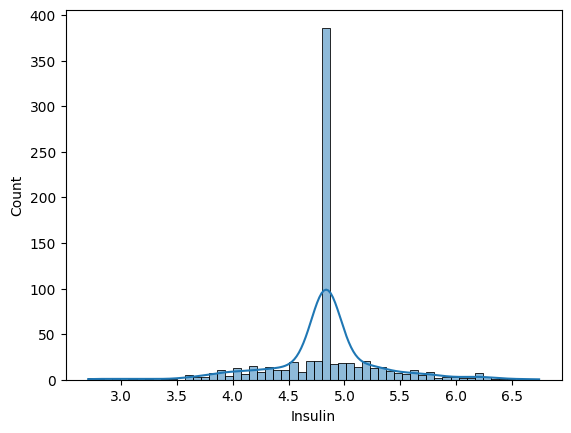

In [107]:
sns.histplot(data["Insulin"],kde=True)

<Axes: xlabel='BloodPressure', ylabel='Count'>

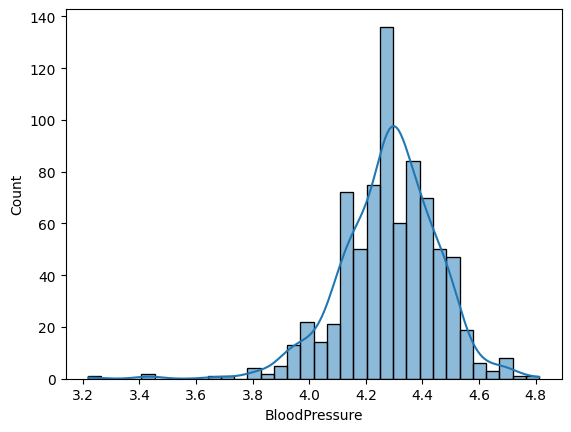

In [108]:
sns.histplot(data["BloodPressure"],kde=True)

<Axes: xlabel='SkinThickness', ylabel='Count'>

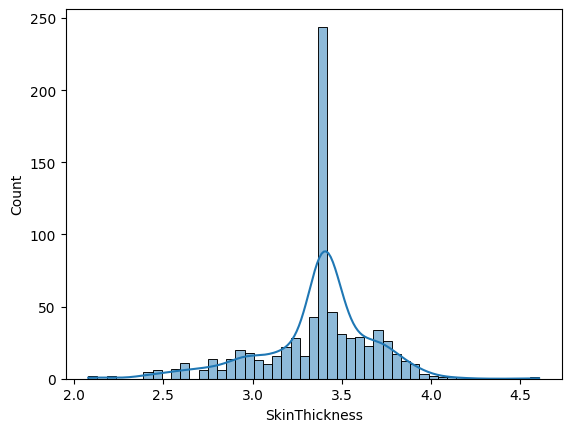

In [109]:
sns.histplot(data["SkinThickness"],kde=True)

<Axes: xlabel='BMI', ylabel='Count'>

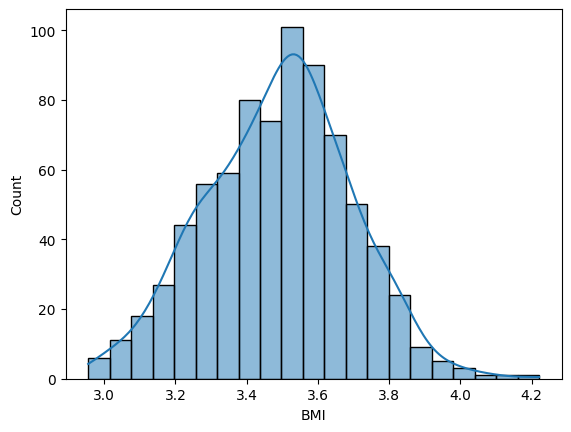

In [110]:
sns.histplot(data["BMI"],kde=True)

<Axes: xlabel='Glucose', ylabel='Count'>

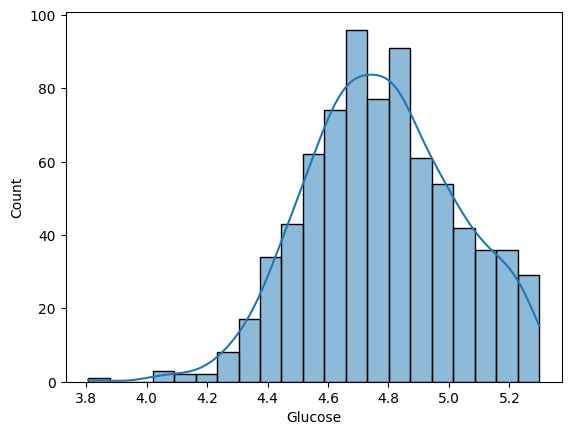

In [111]:
sns.histplot(data["Glucose"],kde=True)

<Axes: >

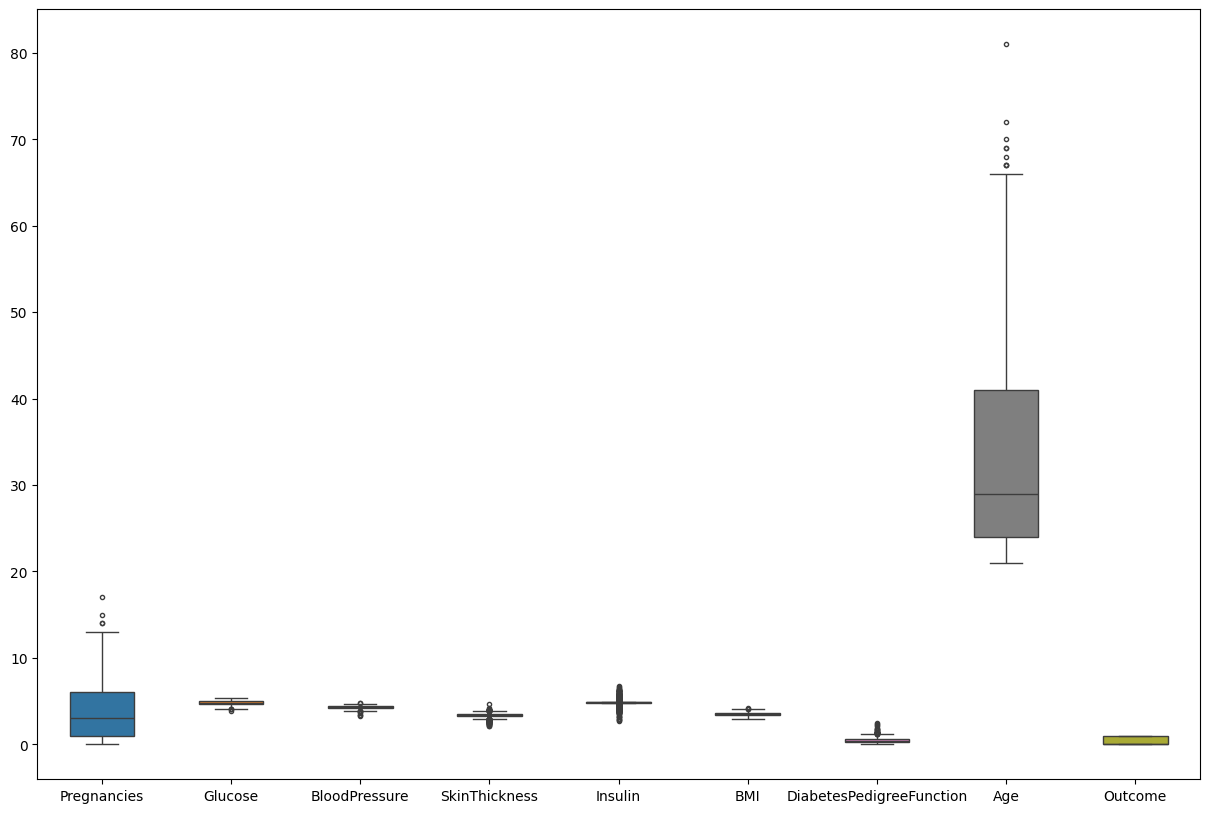

In [112]:
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(data=data, width= 0.5,ax=ax,  fliersize=3)

In [113]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,5.003946,4.290459,3.583519,4.836282,3.543854,0.627,50,1
1,1,4.454347,4.204693,3.401197,4.836282,3.317816,0.351,31,0
2,8,5.214936,4.174387,3.401197,4.836282,3.190476,0.672,32,1
3,1,4.499810,4.204693,3.178054,4.553877,3.370738,0.167,21,0
4,0,4.927254,3.713572,3.583519,5.129899,3.786460,2.288,33,1


In [114]:
## segregate independent feature and independent feature

x=data.drop(columns="Outcome")
y= data["Outcome"]

In [115]:
x_train,x_test,y_train,y_test = train_test_split(x,y)

In [116]:
def scaler_standard(x_train,x_test):
    scaler=StandardScaler()

    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    with open("../Model/StandardScaler.pkl","wb") as f:

        pickle.dump(scaler,f)

        return  x_train_scaled, x_test_scaled

In [117]:
x_train_scaled,x_test_scaled = scaler_standard(x_train,x_test)

In [118]:
logistic_reg = LogisticRegression()



In [119]:
## Finding best hyperparameter tuning using GridSearchCV

## Bydefault GridSearchCV used % for cross validation

from sklearn.model_selection import GridSearchCV

import warnings

warnings.filterwarnings("ignore")

## Parameter grid

parameters = {
    "penalty":["l1","l2"],

    "C":[0.001, 0.01, 0.1, 1, 3, 7, 10, 100],

    "solver": ["lbfgs","liblinear","newton-cg"]

}




In [120]:
clf=GridSearchCV(logistic_reg,param_grid=parameters,scoring="accuracy",cv=10)

clf.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [121]:
clf.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [122]:
clf.best_score_

np.float64(0.7726255293405929)

In [123]:
y_pred = clf.predict(x_test_scaled)
y_pred

array([1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [124]:
y_test

67     0
150    0
74     0
579    1
35     0
      ..
87     0
718    0
588    1
662    1
631    0
Name: Outcome, Length: 192, dtype: int64

In [125]:
cm = confusion_matrix(y_test,y_pred)

In [126]:
print("confusion_matrix",cm)

confusion_matrix [[97 21]
 [27 47]]


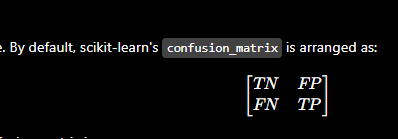

In [127]:
True_Positive=cm[1][1]
True_Negative=cm[0][0]
False_Positive= cm[0][1]
False_Negative= cm[1][0]



In [128]:
##  ✅ correct predictions are = TN+TP = cm[0][0]+cm[1][1]
correct_prediction  = True_Positive + True_Negative
correct_prediction

np.int64(144)

In [129]:
##  ❌ Incorrect predictions are = FN+FP = 16+21 = 37

incorrect_predictions = False_Positive + False_Negative
incorrect_predictions 

np.int64(48)

In [130]:
precision = True_Positive/(True_Positive + False_Positive)
precision

np.float64(0.6911764705882353)

In [131]:
Recall =  True_Positive/(True_Positive+False_Negative)
Recall

np.float64(0.6351351351351351)

In [132]:
accuracy = (True_Positive +True_Negative)/(True_Positive+True_Negative+False_Positive+False_Negative)
accuracy

np.float64(0.75)

## This means the model correctly identified about 66% of the patients who actually had diabetes.

### Now have to store the model in pickle file

In [133]:
with open("../Model/modelForPrediction.pkl","wb") as f:

    pickle.dump(clf,f)